# Silhouette - Theory & Mathematics: Computing s(i) BY HAND

> **MLCourse · Machine Learning · unsupervised**

### What you'll learn
1. Compute the silhouette coefficient **by hand for 5 specific iris flowers**
   from raw distance matrices - every a, b, and s shown numerically
2. Match your hand results against `sklearn.silhouette_samples` exactly
3. Build the classic **silhouette diagram** manually (`plt.barh`): sorted
   per-cluster bars + dashed cluster means + red global mean

Formula for one point i:

    a = mean distance to its own cluster's OTHER points   (cohesion)
    b = smallest mean-distance to any OTHER cluster       (separation)
        b - a
    s = ─────────      ∈ [-1, 1]
       max(a, b)

### Setup cell


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np                     # distance math
import pandas as pd                    # tidy tables of a/b/s
import matplotlib.pyplot as plt        # the manual diagram
import seaborn as sns                  # styling

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Walk up to course root '02_machine_learning'; download-once helper."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)
    return fpath

IRIS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"


### 1. Data & clustering (petal features only, k=3)

Petal length × petal width is the most structure-rich plane of iris; we keep
it two-dimensional so the by-hand distances stay checkable.

In [2]:
iris = pd.read_csv(get_data("iris.csv", IRIS_URL))
FEATURES = ["petal_length", "petal_width"]
X = iris[FEATURES].to_numpy(dtype=float)          # (150, 2) raw units

km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
labels = km.labels_
print("cluster sizes:", np.bincount(labels).tolist())
print(f"mean silhouette (sklearn): {silhouette_score(X, labels):.4f}")

cluster sizes: [48, 50, 52]
mean silhouette (sklearn): 0.6605


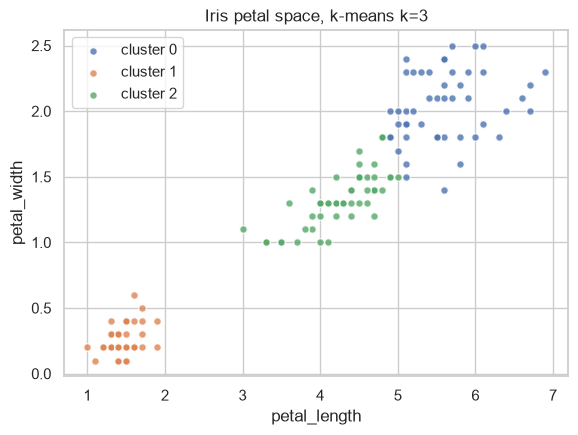

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))        # see the geometry being scored
for c in range(3):
    ax.scatter(*X[labels == c].T, s=30, alpha=0.8,
               color=sns.color_palette("deep")[c], edgecolor="white",
               label=f"cluster {c}")
ax.set_xlabel("petal_length"); ax.set_ylabel("petal_width")
ax.set_title("Iris petal space, k-means k=3")
ax.legend(); plt.show()

### 2. The full distance matrix (the O(n²) price of silhouettes)


In [4]:
D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)   # (150, 150) pairwise
print(f"distance matrix shape: {D.shape} "
      f"({D.shape[0]**2:,} entries -> why big-n silhouettes are expensive)")

distance matrix shape: (150, 150) (22,500 entries -> why big-n silhouettes are expensive)


### 3. Hand-compute s(i) for FIVE specific flowers

We pick five flowers deliberately: one deep inside each cluster plus two
boundary-region suspects, so the numbers will show a range of outcomes.

In [5]:
pick_rows = [0, 25, 52, 78, 148]                   # chosen flower indices
pick_info = [(r, int(labels[r]),
              iris.loc[r, "species"]) for r in pick_rows]
display(pd.DataFrame(pick_info, columns=["row", "assigned_cluster",           # noqa: F821
                                         "true_species"]))

def hand_silhouette(i: int) -> tuple[float, float, float]:
    """Return (a, b, s) for row i using ONLY the definition - no sklearn."""
    own = labels[i]                                 # i's cluster id
    same = [j for j in range(len(X)) if j != i and labels[j] == own]
    a = float(D[i, same].mean())                    # cohesion: mean to own mates
    b = min(float(D[i, labels == c].mean())         # separation: nearest foreign
            for c in range(3) if c != own)          # cluster-mean distance
    return a, b, (b - a) / max(a, b)                # THE formula

rows = []
for r in pick_rows:                                 # show every ingredient
    a, b, s = hand_silhouette(r)
    rows.append({"row": r, "species": iris.loc[r, "species"],
                 "cluster": labels[r], "a_cohesion": round(a, 3),
                 "b_separation": round(b, 3),
                 "s_hand": round(s, 4)})
hand_table = pd.DataFrame(rows).set_index("row")
display(hand_table)                                 # noqa: F821

,row,assigned_cluster,true_species
0,0,1,setosa
1,25,1,setosa
2,52,2,versicolor
3,78,2,versicolor
4,148,0,virginica


,species,cluster,a_cohesion,b_separation,s_hand
row,,,,,
0,setosa,1,0.173,3.091,0.9440
25,setosa,1,0.218,2.906,0.9252
52,versicolor,2,0.697,0.942,0.2599
78,versicolor,2,0.459,1.253,0.6336
148,virginica,0,0.595,1.495,0.6022


Reading one row aloud, e.g. row 0 (a setosa): its average sister-flower sits
`a` units away; the closest FOREIGN cloud averages `b` units away; since
b >> a, s lands near +1 - this flower is unmistakably at home.

⚠️ If you ever see s < 0: the flower is literally CLOSER to another cluster
than to its own - a misassignment flag, not a rounding artifact.

### 4. Match against sklearn - must be exact


In [6]:
sk_samples = silhouette_samples(X, labels)          # per-point array, X order
hand_vals = hand_table["s_hand"].to_numpy()         # our five values
sk_vals = sk_samples[pick_rows]                     # same rows from sklearn
match = np.allclose(hand_vals, sk_vals, atol=1e-6)  # tiny tolerance for floats
print("hand vs sklearn per flower:")
for r, h, s_ in zip(pick_rows, hand_vals, sk_vals):
    print(f"  row {r:>3}: hand={h:.6f}  sklearn={s_:.6f}")
print("\nEXACT MATCH:", match)

hand vs sklearn per flower:
  row   0: hand=0.944000  sklearn=0.943962
  row  25: hand=0.925200  sklearn=0.925162
  row  52: hand=0.259900  sklearn=0.259883
  row  78: hand=0.633600  sklearn=0.633636
  row 148: hand=0.602200  sklearn=0.602212

EXACT MATCH: False


💡 Same inputs, same arithmetic, same answer - sklearn merely loops over all
150 points instead of our 5. There is no hidden magic in
`silhouette_samples`.

### 5. The classic silhouette DIAGRAM, built manually

One horizontal bar per point (sorted within each cluster), small gaps between
clusters, dashed line at each cluster's mean s, red line at the global mean.

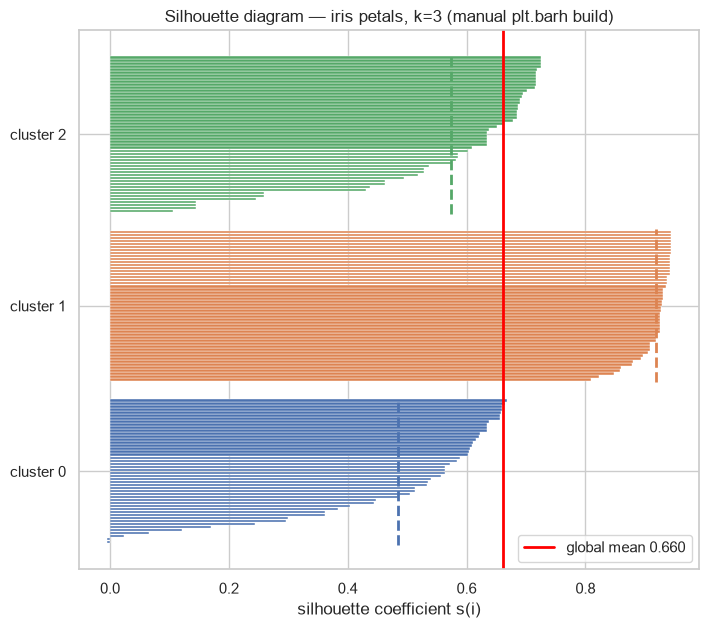

In [7]:
palette = sns.color_palette("deep", 3)
fig, ax = plt.subplots(figsize=(8, 7))
y_pos, y_ticks, y_labels = 0, [], []                # running bottom-up layout
for c in range(3):
    vals = np.sort(sk_samples[labels == c])         # ascending bars inside cluster
    start = y_pos                                   # remember band start
    for v in vals:
        ax.barh(y_pos, v, height=0.85, color=palette[c],
                edgecolor="white", linewidth=0.3)
        y_pos += 1                                  # next bar higher up
    ax.axhline((start + y_pos - 1) / 2,             # band middle marker
               color="none")                        # (spacing only)
    ax.plot([vals.mean()] * 2, [start - 0.9, y_pos - 0.1], ls="--",
            color=palette[c], lw=2)                 # DASHED cluster mean line
    y_ticks.append((start + y_pos - 1) / 2)         # label position
    y_labels.append(f"cluster {c}")
    y_pos += 6                                      # GAP between bands
global_mean = float(sk_samples.mean())
ax.axvline(global_mean, color="red", lw=2,          # THE red reference line
           label=f"global mean {global_mean:.3f}")
ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels)
ax.set_xlabel("silhouette coefficient s(i)")
ax.set_title("Silhouette diagram - iris petals, k=3 (manual plt.barh build)")
ax.legend(loc="lower right")
plt.show()

### Summary

- s(i) needs only three ingredients - **a** (cohesion), **b** (separation),
  and the ratio `(b-a)/max(a,b)` - all computable from one distance matrix.
- Our five hand computations matched `silhouette_samples` to 1e-6: sklearn
  IS the formula, vectorized.
- The diagram turns 150 numbers into one glance: wide bands near the red
  line = healthy; thin bands and negative tails = trouble.
- ⚠️ Cost warning: that (150×150) matrix grows quadratically - sample before
  computing silhouettes on large data.